In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/raw_dataset.csv')

# 1. Konversi Timestamp ke Datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Membersihkan kolom 'Resolved Duration (minutes)'
# Format asli menggunakan '.' untuk ribuan dan ',' untuk desimal (contoh: 8.713,37)
df['Resolved Duration (minutes)'] = (
    df['Resolved Duration (minutes)']
    .str.replace('.', '', regex=False)  # Hapus pemisah ribuan
    .str.replace(',', '.', regex=False)  # Ganti koma desimal ke titik
    .astype(float)
)

print(f"Dataset Shape: {df.shape}")
print(df.info())
display(df.head())

# Cek Missing Values
print("\nMissing Values per Column:")
print(df.isnull().sum())

Dataset Shape: (39259, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39259 entries, 0 to 39258
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   NO                           39259 non-null  int64         
 1   Timestamp                    39259 non-null  datetime64[ns]
 2   Service Type                 37747 non-null  object        
 3   Service Name                 37860 non-null  object        
 4   Type                         39259 non-null  object        
 5   Priority                     39259 non-null  int64         
 6   Impact                       39259 non-null  int64         
 7   Status                       39259 non-null  object        
 8   SLA (minutes)                33679 non-null  float64       
 9   Resolved Time                39259 non-null  object        
 10  Resolved Duration (minutes)  39259 non-null  float64       
 11  Month         

,NO,Timestamp,Service Type,Service Name,Type,Priority,Impact,Status,SLA (minutes),Resolved Time,Resolved Duration (minutes),Month
0,2045,2024-01-01 08:13:45,Inbound,Inbound Contact Center,Restoration,2,2,Closed,45.0,2024-01-01 08:48:06,33.12,Jan
1,2566,2024-01-10 15:06:49,-,-,Restoration,2,2,Closed,90.0,2024-01-11 16:10:11,12.33,Jan
2,2268,2024-01-05 06:11:00,-,-,Restoration,1,1,Closed,210.0,2024-01-05 06:54:47,34.30,Jan
3,2560,2024-01-10 14:19:44,-,-,Restoration,1,1,Closed,210.0,2024-01-10 16:13:57,15.73,Jan
4,2558,2024-01-10 14:02:29,Sosiomedio,Sosiomedio,Restoration,1,1,Closed,210.0,2024-01-10 16:14:56,26.33,Jan



Missing Values per Column:
NO                                0
Timestamp                         0
Service Type                   1512
Service Name                   1399
Type                              0
Priority                          0
Impact                            0
Status                            0
SLA (minutes)                  5580
Resolved Time                     0
Resolved Duration (minutes)       0
Month                             0
dtype: int64


C:\Users\Mahesa\AppData\Local\Temp\ipykernel_18248\2486610598.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Priority', ax=axes[0,0], palette='viridis')
C:\Users\Mahesa\AppData\Local\Temp\ipykernel_18248\2486610598.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Impact', ax=axes[0,1], palette='magma')


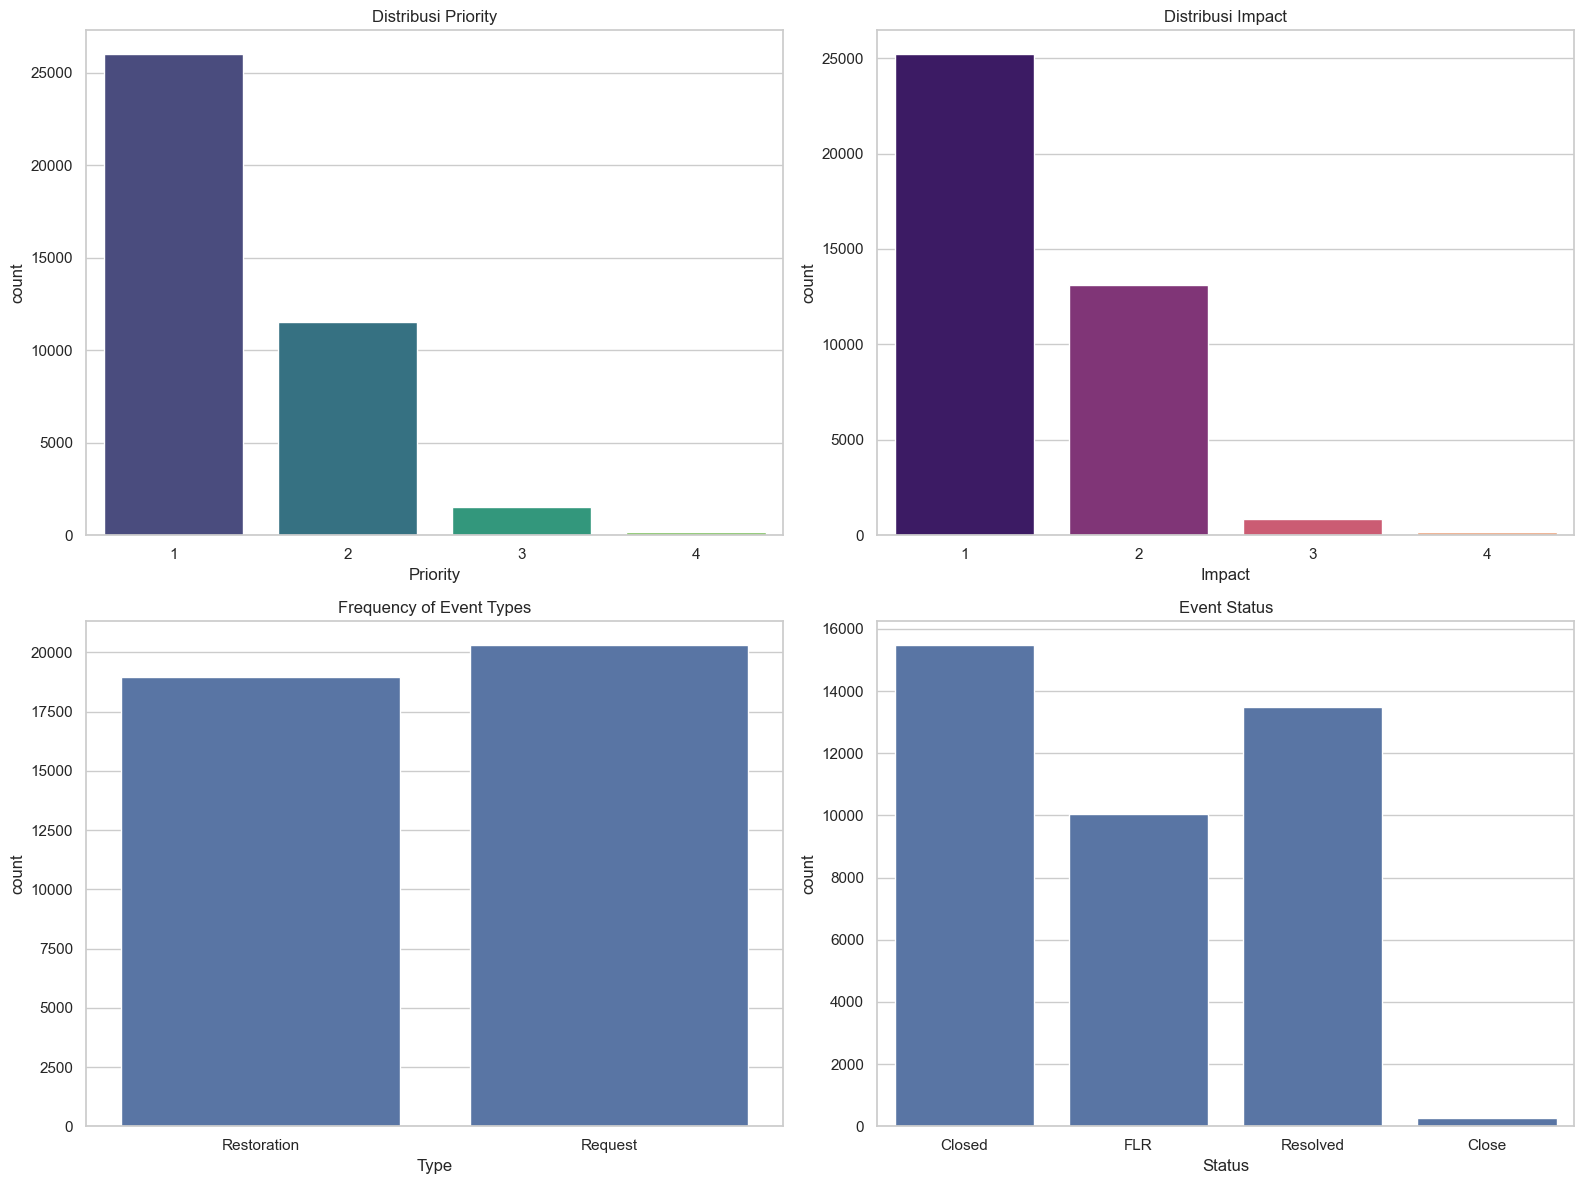

In [2]:
# Setup plot style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Priority Distribution
sns.countplot(data=df, x='Priority', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Distribusi Priority')

# Impact Distribution
sns.countplot(data=df, x='Impact', ax=axes[0,1], palette='magma')
axes[0,1].set_title('Distribusi Impact')

# Event Type (Incident vs Maintenance/Lainnya)
sns.countplot(data=df, x='Type', ax=axes[1,0])
axes[1,0].set_title('Frequency of Event Types')

# Status
sns.countplot(data=df, x='Status', ax=axes[1,1])
axes[1,1].set_title('Event Status')

plt.tight_layout()
plt.show()

# Advanced EDA: Non-Linear Correlations & Feature Engineering

Analisis mendalam untuk menemukan:
1. **Temporal Patterns** - Hour, day of week, shift patterns
2. **Non-Linear Correlations** - Mutual Information, Distance Correlation
3. **Interaction Features** - Priority × Impact, Duration ratios
4. **SLA Breach Patterns** - Breach indicators and risk factors
5. **Clustering Analysis** - Hidden patterns in data

In [3]:
# Import additional libraries for advanced analysis
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Feature Engineering: Temporal Features

Extract comprehensive time-based features that might have non-linear relationships with incidents.

In [4]:
# Create a copy for feature engineering
df_fe = df.copy()

# Filter restoration tickets only (seperti preprocessing)
df_fe = df_fe[df_fe['Type'].str.contains('restoration', case=False, na=False)].copy()

# Create incident label
df_fe['incident'] = ((df_fe['Priority'] >= 2) & (df_fe['Impact'] >= 2)).astype(int)

# ========== TEMPORAL FEATURES ==========
# Hour of day
df_fe['hour'] = df_fe['Timestamp'].dt.hour
df_fe['minute'] = df_fe['Timestamp'].dt.minute

# Day of week (0=Monday, 6=Sunday)
df_fe['day_of_week'] = df_fe['Timestamp'].dt.dayofweek
df_fe['day_name'] = df_fe['Timestamp'].dt.day_name()

# Weekend indicator
df_fe['is_weekend'] = (df_fe['day_of_week'] >= 5).astype(int)

# Shift patterns (0: night, 1: morning, 2: afternoon, 3: evening)
def get_shift(hour):
    if hour < 6:
        return 0  # Night shift (00:00 - 06:00)
    elif hour < 12:
        return 1  # Morning shift (06:00 - 12:00)
    elif hour < 18:
        return 2  # Afternoon shift (12:00 - 18:00)
    else:
        return 3  # Evening shift (18:00 - 24:00)

df_fe['shift'] = df_fe['hour'].apply(get_shift)
shift_names = {0: 'Night', 1: 'Morning', 2: 'Afternoon', 3: 'Evening'}
df_fe['shift_name'] = df_fe['shift'].map(shift_names)

# Business hours indicator (8 AM - 5 PM on weekdays)
df_fe['is_business_hours'] = (
    (df_fe['hour'] >= 8) & 
    (df_fe['hour'] < 17) & 
    (df_fe['day_of_week'] < 5)
).astype(int)

# Peak hours (based on typical call center patterns)
df_fe['is_peak_hours'] = (
    ((df_fe['hour'] >= 9) & (df_fe['hour'] <= 11)) |  # Morning peak
    ((df_fe['hour'] >= 14) & (df_fe['hour'] <= 16))   # Afternoon peak
).astype(int)

# Cyclical encoding for hour (to capture circular nature of time)
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)

# Cyclical encoding for day of week
df_fe['day_sin'] = np.sin(2 * np.pi * df_fe['day_of_week'] / 7)
df_fe['day_cos'] = np.cos(2 * np.pi * df_fe['day_of_week'] / 7)

# Month features
df_fe['month'] = df_fe['Timestamp'].dt.month
df_fe['day_of_month'] = df_fe['Timestamp'].dt.day

# Week of year
df_fe['week_of_year'] = df_fe['Timestamp'].dt.isocalendar().week

print(f"Shape after filtering restoration: {df_fe.shape}")
print(f"\nIncident distribution:")
print(df_fe['incident'].value_counts())
print(f"\nNew temporal features created: {len([col for col in df_fe.columns if col not in df.columns])}")
print("\nTemporal features preview:")
display(df_fe[['Timestamp', 'hour', 'day_of_week', 'shift_name', 'is_weekend', 
               'is_business_hours', 'is_peak_hours', 'incident']].head(10))

Shape after filtering restoration: (18969, 29)

Incident distribution:
incident
0    11136
1     7833
Name: count, dtype: int64

New temporal features created: 17

Temporal features preview:


,Timestamp,hour,day_of_week,shift_name,is_weekend,is_business_hours,is_peak_hours,incident
0,2024-01-01 08:13:45,8,0,Morning,0,1,0,1
1,2024-01-10 15:06:49,15,2,Afternoon,0,1,1,1
2,2024-01-05 06:11:00,6,4,Morning,0,0,0,0
3,2024-01-10 14:19:44,14,2,Afternoon,0,1,1,0
4,2024-01-10 14:02:29,14,2,Afternoon,0,1,1,0
9,2024-01-01 06:04:58,6,0,Morning,0,0,0,0
11,2024-01-01 07:03:17,7,0,Morning,0,0,0,0
12,2024-01-01 15:31:35,15,0,Afternoon,0,1,1,0
17,2024-01-10 16:25:43,16,2,Afternoon,0,1,1,1
19,2024-01-05 14:40:26,14,4,Afternoon,0,1,1,1


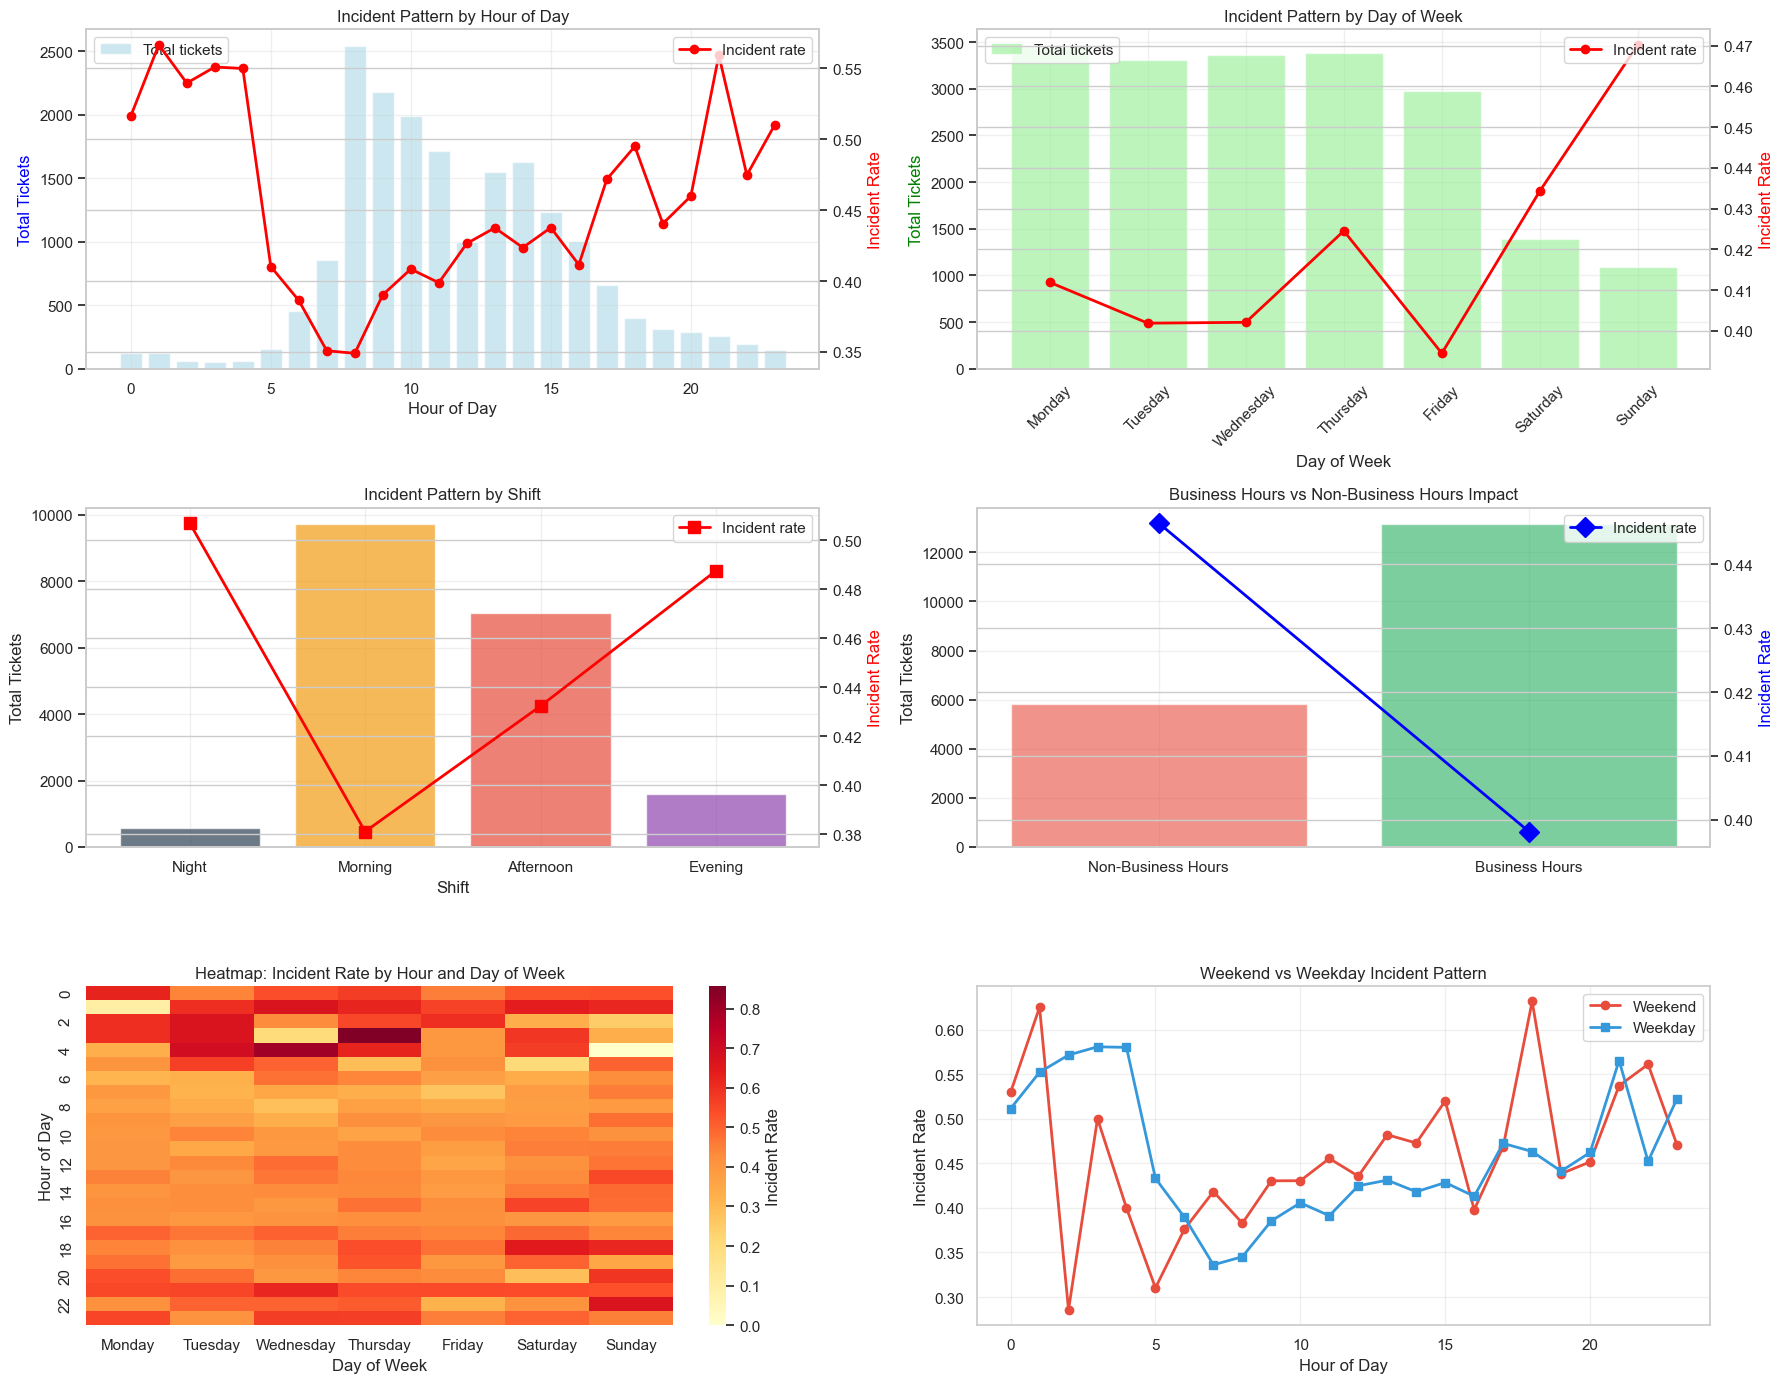


TEMPORAL PATTERN INSIGHTS

1. HIGHEST INCIDENT RATE BY HOUR: 1:00 (56.67%)
2. LOWEST INCIDENT RATE BY HOUR: 8:00 (34.91%)

3. HIGHEST INCIDENT RATE BY DAY: Sunday (47.02%)
4. LOWEST INCIDENT RATE BY DAY: Friday (39.45%)

5. HIGHEST INCIDENT RATE BY SHIFT: Night (50.70%)
6. LOWEST INCIDENT RATE BY SHIFT: Morning (38.11%)

7. BUSINESS HOURS INCIDENT RATE: 39.82%
8. NON-BUSINESS HOURS INCIDENT RATE: 44.64%

9. WEEKEND INCIDENT RATE: 45.01%
10. WEEKDAY INCIDENT RATE: 40.73%


In [5]:
# Visualize Temporal Patterns
fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# 1. Incidents by Hour of Day
hour_incident_rate = df_fe.groupby('hour')['incident'].agg(['sum', 'count', 'mean'])
axes[0,0].bar(hour_incident_rate.index, hour_incident_rate['count'], alpha=0.6, label='Total tickets', color='lightblue')
ax_twin = axes[0,0].twinx()
ax_twin.plot(hour_incident_rate.index, hour_incident_rate['mean'], color='red', marker='o', linewidth=2, label='Incident rate')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Total Tickets', color='blue')
ax_twin.set_ylabel('Incident Rate', color='red')
axes[0,0].set_title('Incident Pattern by Hour of Day')
axes[0,0].legend(loc='upper left')
ax_twin.legend(loc='upper right')
axes[0,0].grid(alpha=0.3)

# 2. Incidents by Day of Week
day_incident_rate = df_fe.groupby('day_name')['incident'].agg(['sum', 'count', 'mean'])
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_incident_rate = day_incident_rate.reindex(day_order)
axes[0,1].bar(range(len(day_incident_rate)), day_incident_rate['count'], alpha=0.6, label='Total tickets', color='lightgreen')
ax_twin2 = axes[0,1].twinx()
ax_twin2.plot(range(len(day_incident_rate)), day_incident_rate['mean'], color='red', marker='o', linewidth=2, label='Incident rate')
axes[0,1].set_xticks(range(len(day_incident_rate)))
axes[0,1].set_xticklabels(day_incident_rate.index, rotation=45)
axes[0,1].set_xlabel('Day of Week')
axes[0,1].set_ylabel('Total Tickets', color='green')
ax_twin2.set_ylabel('Incident Rate', color='red')
axes[0,1].set_title('Incident Pattern by Day of Week')
axes[0,1].legend(loc='upper left')
ax_twin2.legend(loc='upper right')
axes[0,1].grid(alpha=0.3)

# 3. Incidents by Shift
shift_incident_rate = df_fe.groupby('shift_name')['incident'].agg(['sum', 'count', 'mean'])
shift_order = ['Night', 'Morning', 'Afternoon', 'Evening']
shift_incident_rate = shift_incident_rate.reindex(shift_order)
colors = ['#2E4053', '#F39C12', '#E74C3C', '#8E44AD']
axes[1,0].bar(shift_incident_rate.index, shift_incident_rate['count'], alpha=0.7, color=colors)
ax_twin3 = axes[1,0].twinx()
ax_twin3.plot(shift_incident_rate.index, shift_incident_rate['mean'], color='red', marker='s', linewidth=2, markersize=8, label='Incident rate')
axes[1,0].set_xlabel('Shift')
axes[1,0].set_ylabel('Total Tickets')
ax_twin3.set_ylabel('Incident Rate', color='red')
axes[1,0].set_title('Incident Pattern by Shift')
ax_twin3.legend(loc='upper right')
axes[1,0].grid(alpha=0.3)

# 4. Business Hours vs Non-Business Hours
bh_comparison = df_fe.groupby('is_business_hours')['incident'].agg(['sum', 'count', 'mean'])
bh_labels = ['Non-Business Hours', 'Business Hours']
axes[1,1].bar(bh_labels, bh_comparison['count'], alpha=0.6, color=['#E74C3C', '#27AE60'])
ax_twin4 = axes[1,1].twinx()
ax_twin4.plot(bh_labels, bh_comparison['mean'], color='blue', marker='D', linewidth=2, markersize=10, label='Incident rate')
axes[1,1].set_ylabel('Total Tickets')
ax_twin4.set_ylabel('Incident Rate', color='blue')
axes[1,1].set_title('Business Hours vs Non-Business Hours Impact')
ax_twin4.legend(loc='upper right')
axes[1,1].grid(alpha=0.3)

# 5. Heatmap: Hour vs Day of Week
pivot_table = df_fe.pivot_table(values='incident', index='hour', columns='day_name', aggfunc='mean')
pivot_table = pivot_table[day_order]
sns.heatmap(pivot_table, cmap='YlOrRd', annot=False, fmt='.2f', cbar_kws={'label': 'Incident Rate'}, ax=axes[2,0])
axes[2,0].set_title('Heatmap: Incident Rate by Hour and Day of Week')
axes[2,0].set_xlabel('Day of Week')
axes[2,0].set_ylabel('Hour of Day')

# 6. Weekend vs Weekday comparison by hour
weekend_data = df_fe[df_fe['is_weekend']==1].groupby('hour')['incident'].mean()
weekday_data = df_fe[df_fe['is_weekend']==0].groupby('hour')['incident'].mean()
axes[2,1].plot(weekend_data.index, weekend_data.values, marker='o', linewidth=2, label='Weekend', color='#E74C3C')
axes[2,1].plot(weekday_data.index, weekday_data.values, marker='s', linewidth=2, label='Weekday', color='#3498DB')
axes[2,1].set_xlabel('Hour of Day')
axes[2,1].set_ylabel('Incident Rate')
axes[2,1].set_title('Weekend vs Weekday Incident Pattern')
axes[2,1].legend()
axes[2,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print insights
print("\n" + "="*80)
print("TEMPORAL PATTERN INSIGHTS")
print("="*80)
print(f"\n1. HIGHEST INCIDENT RATE BY HOUR: {hour_incident_rate['mean'].idxmax()}:00 ({hour_incident_rate['mean'].max():.2%})")
print(f"2. LOWEST INCIDENT RATE BY HOUR: {hour_incident_rate['mean'].idxmin()}:00 ({hour_incident_rate['mean'].min():.2%})")
print(f"\n3. HIGHEST INCIDENT RATE BY DAY: {day_incident_rate['mean'].idxmax()} ({day_incident_rate['mean'].max():.2%})")
print(f"4. LOWEST INCIDENT RATE BY DAY: {day_incident_rate['mean'].idxmin()} ({day_incident_rate['mean'].min():.2%})")
print(f"\n5. HIGHEST INCIDENT RATE BY SHIFT: {shift_incident_rate['mean'].idxmax()} ({shift_incident_rate['mean'].max():.2%})")
print(f"6. LOWEST INCIDENT RATE BY SHIFT: {shift_incident_rate['mean'].idxmin()} ({shift_incident_rate['mean'].min():.2%})")
print(f"\n7. BUSINESS HOURS INCIDENT RATE: {bh_comparison.loc[1, 'mean']:.2%}")
print(f"8. NON-BUSINESS HOURS INCIDENT RATE: {bh_comparison.loc[0, 'mean']:.2%}")
print(f"\n9. WEEKEND INCIDENT RATE: {df_fe[df_fe['is_weekend']==1]['incident'].mean():.2%}")
print(f"10. WEEKDAY INCIDENT RATE: {df_fe[df_fe['is_weekend']==0]['incident'].mean():.2%}")

## 2. Interaction Features & SLA Analysis

Create features that capture non-linear relationships between variables.

In [6]:
# ========== INTERACTION FEATURES ==========

# 1. Priority × Impact (critical indicator)
df_fe['priority_impact_product'] = df_fe['Priority'] * df_fe['Impact']
df_fe['priority_impact_sum'] = df_fe['Priority'] + df_fe['Impact']
df_fe['priority_impact_diff'] = abs(df_fe['Priority'] - df_fe['Impact'])
df_fe['priority_impact_max'] = df_fe[['Priority', 'Impact']].max(axis=1)
df_fe['priority_impact_min'] = df_fe[['Priority', 'Impact']].min(axis=1)

# 2. Squared features (non-linear transformations)
df_fe['priority_squared'] = df_fe['Priority'] ** 2
df_fe['impact_squared'] = df_fe['Impact'] ** 2

# 3. SLA-related features
df_fe['has_sla'] = (~df_fe['SLA (minutes)'].isna()).astype(int)

# For rows with SLA, calculate breach risk
df_fe['sla_duration_ratio'] = df_fe['Resolved Duration (minutes)'] / (df_fe['SLA (minutes)'] + 1e-6)
df_fe['sla_breach'] = (df_fe['Resolved Duration (minutes)'] > df_fe['SLA (minutes)']).astype(int)

# SLA pressure indicator (how close to SLA limit)
df_fe['sla_pressure'] = np.where(
    df_fe['SLA (minutes)'].notna(),
    np.clip(df_fe['sla_duration_ratio'], 0, 2),  # Cap at 200%
    0
)

# 4. Duration-based features
df_fe['log_duration'] = np.log1p(df_fe['Resolved Duration (minutes)'])
df_fe['sqrt_duration'] = np.sqrt(df_fe['Resolved Duration (minutes)'])

# Duration category (binning)
df_fe['duration_category'] = pd.cut(
    df_fe['Resolved Duration (minutes)'],
    bins=[0, 10, 30, 60, 120, np.inf],
    labels=['Very Fast (<10min)', 'Fast (10-30min)', 'Medium (30-60min)', 'Slow (1-2h)', 'Very Slow (>2h)']
)

# 5. Time interaction with Priority/Impact
df_fe['priority_hour_interaction'] = df_fe['Priority'] * df_fe['hour']
df_fe['impact_hour_interaction'] = df_fe['Impact'] * df_fe['hour']
df_fe['priority_shift_interaction'] = df_fe['Priority'] * df_fe['shift']

# 6. Composite risk score
df_fe['risk_score'] = (
    df_fe['Priority'] * 0.4 + 
    df_fe['Impact'] * 0.4 + 
    df_fe['is_peak_hours'] * 0.1 +
    (1 - df_fe['is_business_hours']) * 0.1
)

print("Interaction features created!")
print(f"\nTotal features now: {df_fe.shape[1]}")
print("\nInteraction features sample:")
display(df_fe[['Priority', 'Impact', 'priority_impact_product', 'priority_impact_sum', 
               'sla_breach', 'sla_pressure', 'risk_score', 'incident']].head(10))

Interaction features created!

Total features now: 47

Interaction features sample:


,Priority,Impact,priority_impact_product,priority_impact_sum,sla_breach,sla_pressure,risk_score,incident
0,2,2,4,4,0,0.736000,1.6,1
1,2,2,4,4,0,0.137000,1.7,1
2,1,1,1,2,0,0.163333,0.9,0
3,1,1,1,2,0,0.074905,0.9,0
4,1,1,1,2,0,0.125381,0.9,0
9,1,1,1,2,0,0.068190,0.9,0
11,1,1,1,2,0,0.036000,0.9,0
12,1,1,1,2,0,0.025556,0.9,0
17,2,2,4,4,1,2.000000,1.7,1
19,2,2,4,4,0,0.359500,1.7,1


## 3. Non-Linear Correlation Analysis

Analyze non-linear relationships using:
- **Mutual Information**: Measures statistical dependence (captures non-linear relationships)
- **Spearman Correlation**: Rank-based correlation (monotonic relationships)
- **Pearson Correlation**: Linear correlation (baseline comparison)

In [7]:
# Select numerical features for correlation analysis
numerical_features = [
    'Priority', 'Impact', 'hour', 'day_of_week', 'shift', 
    'is_weekend', 'is_business_hours', 'is_peak_hours',
    'priority_impact_product', 'priority_impact_sum', 'priority_impact_diff',
    'priority_squared', 'impact_squared',
    'sla_pressure', 'sla_breach', 'has_sla',
    'log_duration', 'sqrt_duration',
    'priority_hour_interaction', 'impact_hour_interaction',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'risk_score', 'month', 'week_of_year'
]

# Filter to existing columns and no NaN issues
available_features = [f for f in numerical_features if f in df_fe.columns]

# Create feature matrix
X_corr = df_fe[available_features].fillna(0)
y_corr = df_fe['incident'].values

print(f"Analyzing {len(available_features)} features for non-linear correlations with 'incident'...\n")

# ========== 1. MUTUAL INFORMATION (Non-linear dependence) ==========
print("Calculating Mutual Information (captures non-linear relationships)...")
mi_scores = mutual_info_classif(X_corr, y_corr, discrete_features='auto', random_state=42)
mi_df = pd.DataFrame({
    'Feature': available_features,
    'Mutual_Information': mi_scores
}).sort_values('Mutual_Information', ascending=False)

# ========== 2. SPEARMAN CORRELATION (Monotonic relationships) ==========
print("Calculating Spearman Correlation (rank-based, captures monotonic non-linearity)...")
spearman_scores = []
for feature in available_features:
    corr, _ = spearmanr(X_corr[feature], y_corr)
    spearman_scores.append(abs(corr))  # Absolute value for importance

spearman_df = pd.DataFrame({
    'Feature': available_features,
    'Spearman_Abs': spearman_scores
}).sort_values('Spearman_Abs', ascending=False)

# ========== 3. PEARSON CORRELATION (Linear relationships - baseline) ==========
print("Calculating Pearson Correlation (linear relationships)...")
pearson_scores = []
for feature in available_features:
    corr, _ = pearsonr(X_corr[feature], y_corr)
    pearson_scores.append(abs(corr))  # Absolute value for importance

pearson_df = pd.DataFrame({
    'Feature': available_features,
    'Pearson_Abs': pearson_scores
}).sort_values('Pearson_Abs', ascending=False)

# ========== COMBINE ALL METRICS ==========
correlation_summary = mi_df.copy()
correlation_summary = correlation_summary.merge(spearman_df, on='Feature')
correlation_summary = correlation_summary.merge(pearson_df, on='Feature')

# Calculate composite score (weighted average)
correlation_summary['Composite_Score'] = (
    correlation_summary['Mutual_Information'] * 0.5 +  # MI is most important for non-linearity
    correlation_summary['Spearman_Abs'] * 0.3 +
    correlation_summary['Pearson_Abs'] * 0.2
)
correlation_summary = correlation_summary.sort_values('Composite_Score', ascending=False)

# Identify non-linear features (high MI, low Pearson)
correlation_summary['NonLinear_Ratio'] = correlation_summary['Mutual_Information'] / (correlation_summary['Pearson_Abs'] + 0.01)
correlation_summary['Is_NonLinear'] = (
    (correlation_summary['NonLinear_Ratio'] > 1.5) | 
    ((correlation_summary['Mutual_Information'] > 0.05) & (correlation_summary['Pearson_Abs'] < 0.1))
)

print("\n" + "="*100)
print("TOP 15 FEATURES BY COMPOSITE SCORE (Combining MI, Spearman, Pearson)")
print("="*100)
display(correlation_summary.head(15)[[
    'Feature', 'Mutual_Information', 'Spearman_Abs', 'Pearson_Abs', 
    'Composite_Score', 'NonLinear_Ratio', 'Is_NonLinear'
]].style.background_gradient(subset=['Mutual_Information', 'Spearman_Abs', 'Pearson_Abs', 'Composite_Score'], cmap='YlOrRd'))

print("\n" + "="*100)
print("HIGHLY NON-LINEAR FEATURES (High MI but Low Pearson correlation)")
print("="*100)
nonlinear_features = correlation_summary[correlation_summary['Is_NonLinear'] == True].head(10)
display(nonlinear_features[[
    'Feature', 'Mutual_Information', 'Spearman_Abs', 'Pearson_Abs', 'NonLinear_Ratio'
]])

# Store for later use
top_features_mi = mi_df.head(10)['Feature'].tolist()
top_features_composite = correlation_summary.head(15)['Feature'].tolist()

print(f"\n✓ Top 10 features by Mutual Information: {top_features_mi}")
print(f"\n✓ Top 15 features by Composite Score: {top_features_composite}")

Analyzing 27 features for non-linear correlations with 'incident'...

Calculating Mutual Information (captures non-linear relationships)...
Calculating Spearman Correlation (rank-based, captures monotonic non-linearity)...
Calculating Pearson Correlation (linear relationships)...

TOP 15 FEATURES BY COMPOSITE SCORE (Combining MI, Spearman, Pearson)


,Feature,Mutual_Information,Spearman_Abs,Pearson_Abs,Composite_Score,NonLinear_Ratio,Is_NonLinear
1,priority_impact_sum,0.675466,0.926893,0.886602,0.793121,0.753362,False
0,priority_impact_product,0.676992,0.927500,0.806509,0.778048,0.829129,False
2,risk_score,0.675194,0.876835,0.882272,0.777102,0.756714,False
4,Priority,0.563965,0.916612,0.851955,0.727357,0.654286,False
3,priority_squared,0.564311,0.916612,0.755458,0.708231,0.737220,False
5,Impact,0.519301,0.889751,0.836910,0.693958,0.613171,False
6,impact_squared,0.518194,0.889751,0.741864,0.674395,0.689213,False
7,priority_hour_interaction,0.401583,0.702593,0.647187,0.541007,0.611064,False
8,impact_hour_interaction,0.367287,0.674353,0.623950,0.510739,0.579363,False
10,log_duration,0.023760,0.180879,0.149064,0.095957,0.149372,False



HIGHLY NON-LINEAR FEATURES (High MI but Low Pearson correlation)


,Feature,Mutual_Information,Spearman_Abs,Pearson_Abs,NonLinear_Ratio



✓ Top 10 features by Mutual Information: ['priority_impact_product', 'priority_impact_sum', 'risk_score', 'priority_squared', 'Priority', 'Impact', 'impact_squared', 'priority_hour_interaction', 'impact_hour_interaction', 'sla_pressure']

✓ Top 15 features by Composite Score: ['priority_impact_sum', 'priority_impact_product', 'risk_score', 'Priority', 'priority_squared', 'Impact', 'impact_squared', 'priority_hour_interaction', 'impact_hour_interaction', 'log_duration', 'sqrt_duration', 'month', 'week_of_year', 'sla_pressure', 'sla_breach']


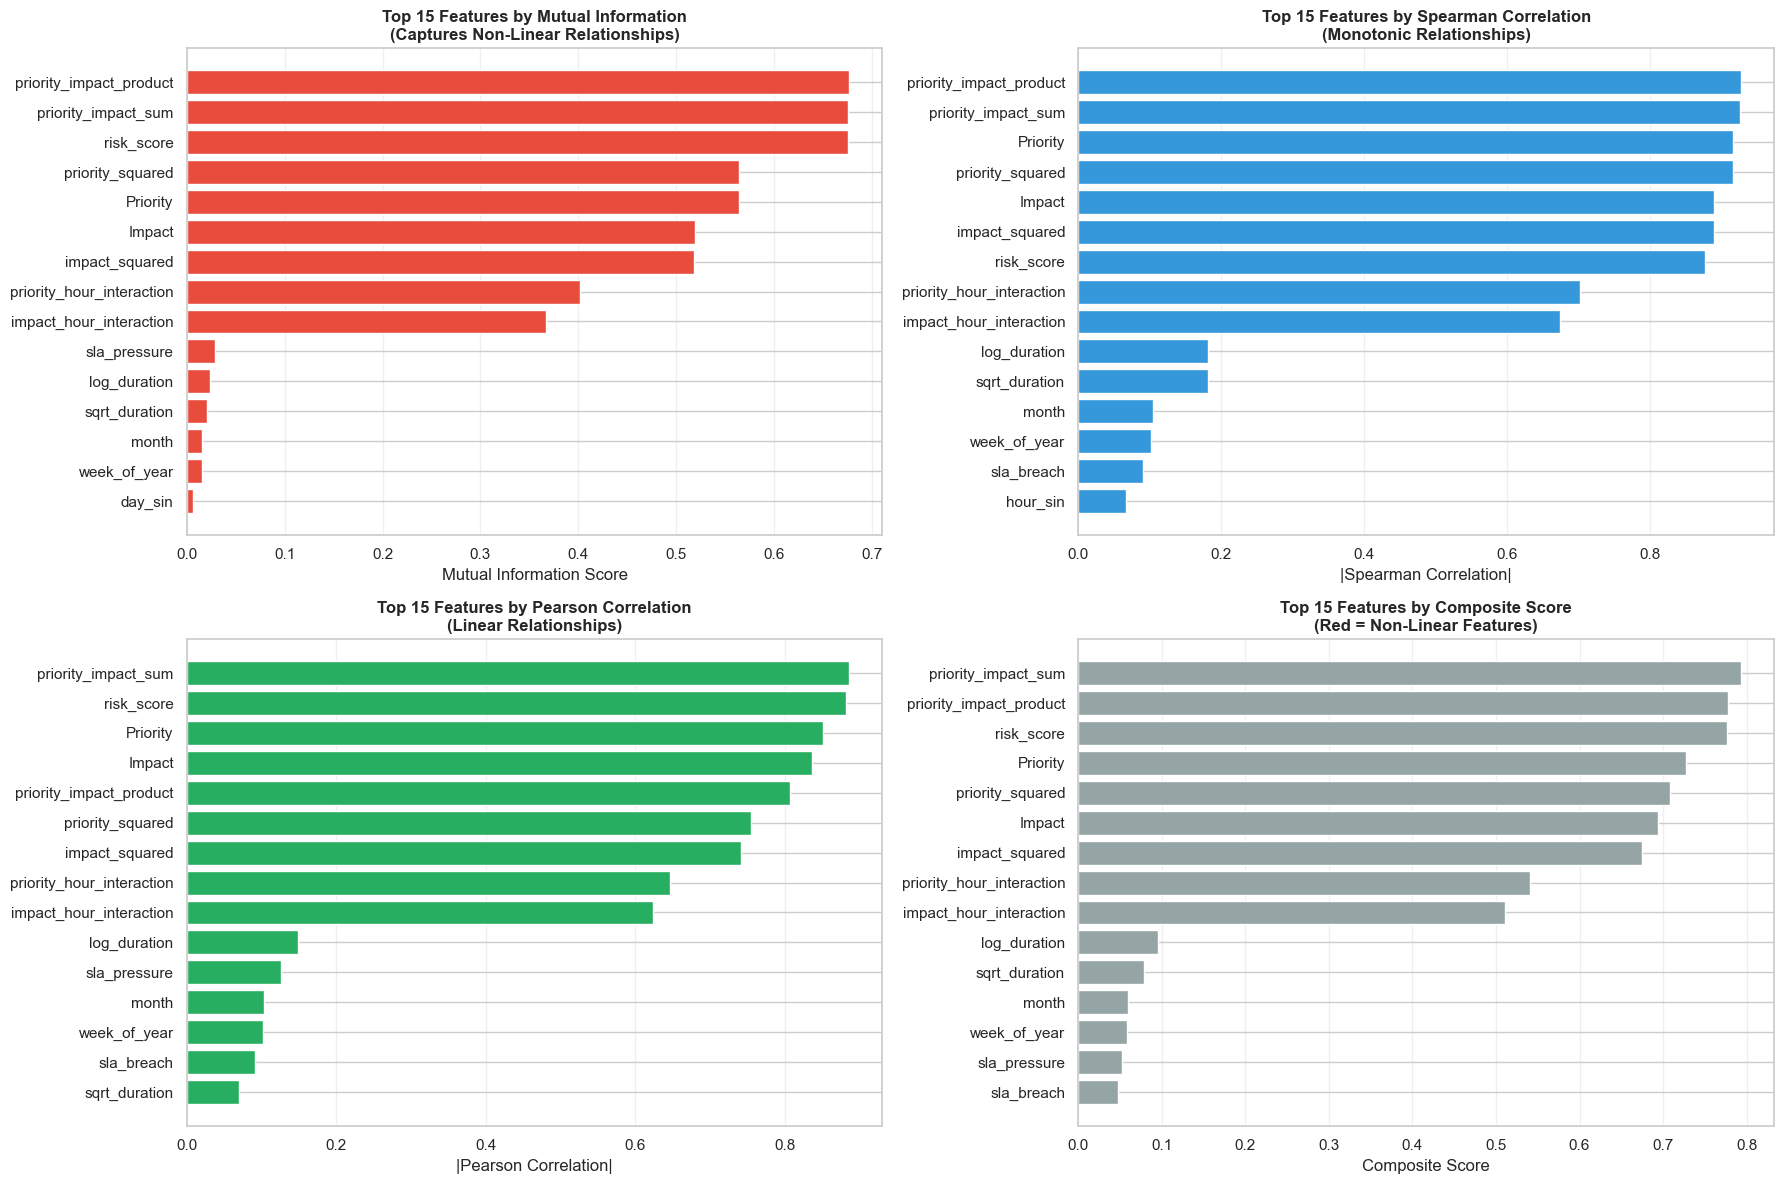

In [8]:
# Visualize correlation comparison across methods
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top features by Mutual Information
top_n = 15
mi_top = mi_df.head(top_n)
axes[0,0].barh(range(len(mi_top)), mi_top['Mutual_Information'].values, color='#E74C3C')
axes[0,0].set_yticks(range(len(mi_top)))
axes[0,0].set_yticklabels(mi_top['Feature'].values)
axes[0,0].set_xlabel('Mutual Information Score')
axes[0,0].set_title(f'Top {top_n} Features by Mutual Information\n(Captures Non-Linear Relationships)', fontsize=12, fontweight='bold')
axes[0,0].invert_yaxis()
axes[0,0].grid(axis='x', alpha=0.3)

# 2. Top features by Spearman
spearman_top = spearman_df.head(top_n)
axes[0,1].barh(range(len(spearman_top)), spearman_top['Spearman_Abs'].values, color='#3498DB')
axes[0,1].set_yticks(range(len(spearman_top)))
axes[0,1].set_yticklabels(spearman_top['Feature'].values)
axes[0,1].set_xlabel('|Spearman Correlation|')
axes[0,1].set_title(f'Top {top_n} Features by Spearman Correlation\n(Monotonic Relationships)', fontsize=12, fontweight='bold')
axes[0,1].invert_yaxis()
axes[0,1].grid(axis='x', alpha=0.3)

# 3. Top features by Pearson (baseline)
pearson_top = pearson_df.head(top_n)
axes[1,0].barh(range(len(pearson_top)), pearson_top['Pearson_Abs'].values, color='#27AE60')
axes[1,0].set_yticks(range(len(pearson_top)))
axes[1,0].set_yticklabels(pearson_top['Feature'].values)
axes[1,0].set_xlabel('|Pearson Correlation|')
axes[1,0].set_title(f'Top {top_n} Features by Pearson Correlation\n(Linear Relationships)', fontsize=12, fontweight='bold')
axes[1,0].invert_yaxis()
axes[1,0].grid(axis='x', alpha=0.3)

# 4. Composite Score (combined ranking)
composite_top = correlation_summary.head(top_n)
colors_composite = ['#E74C3C' if is_nl else '#95A5A6' for is_nl in composite_top['Is_NonLinear']]
axes[1,1].barh(range(len(composite_top)), composite_top['Composite_Score'].values, color=colors_composite)
axes[1,1].set_yticks(range(len(composite_top)))
axes[1,1].set_yticklabels(composite_top['Feature'].values)
axes[1,1].set_xlabel('Composite Score')
axes[1,1].set_title(f'Top {top_n} Features by Composite Score\n(Red = Non-Linear Features)', fontsize=12, fontweight='bold')
axes[1,1].invert_yaxis()
axes[1,1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

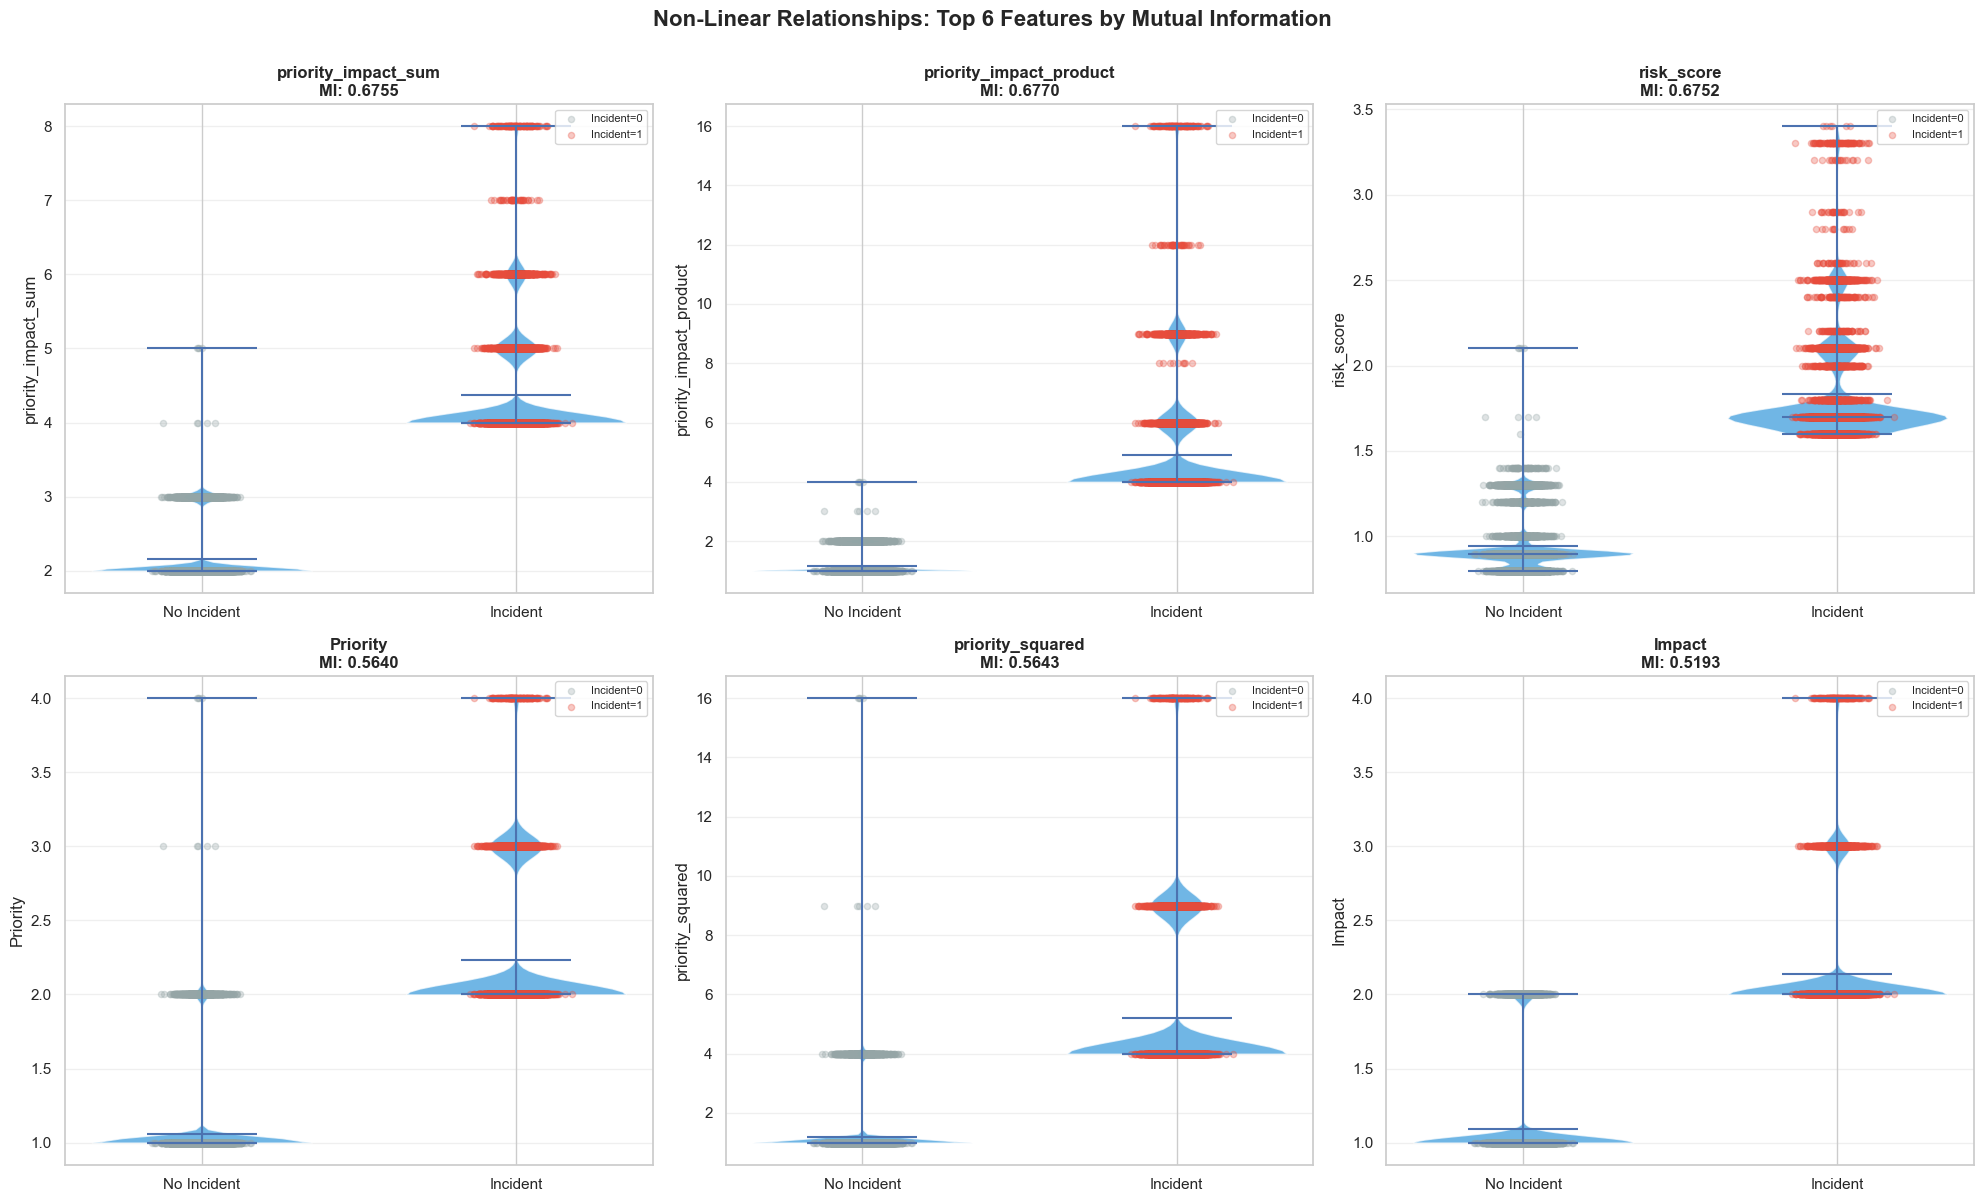

In [9]:
# Visualize non-linear relationships for top features
top_6_features = correlation_summary.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_6_features):
    ax = axes[idx]
    
    # Create violin plot showing distribution by incident status
    parts = ax.violinplot(
        [df_fe[df_fe['incident']==0][feature].dropna(), 
         df_fe[df_fe['incident']==1][feature].dropna()],
        positions=[0, 1],
        showmeans=True,
        showmedians=True,
        widths=0.7
    )
    
    # Color coding
    for pc in parts['bodies']:
        pc.set_facecolor('#3498DB')
        pc.set_alpha(0.7)
    
    # Add scatter points with jitter
    np.random.seed(42)
    for incident_val, position, color in [(0, 0, '#95A5A6'), (1, 1, '#E74C3C')]:
        data = df_fe[df_fe['incident']==incident_val][feature].dropna()
        jitter = np.random.normal(0, 0.04, size=len(data))
        ax.scatter(position + jitter, data, alpha=0.3, s=20, color=color, label=f'Incident={incident_val}')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Incident', 'Incident'])
    ax.set_ylabel(feature)
    ax.set_title(f'{feature}\nMI: {correlation_summary[correlation_summary["Feature"]==feature]["Mutual_Information"].values[0]:.4f}', 
                 fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Non-Linear Relationships: Top 6 Features by Mutual Information', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 4. Clustering Analysis

Discover hidden patterns and segment tickets into clusters to find distinct behavioral groups.

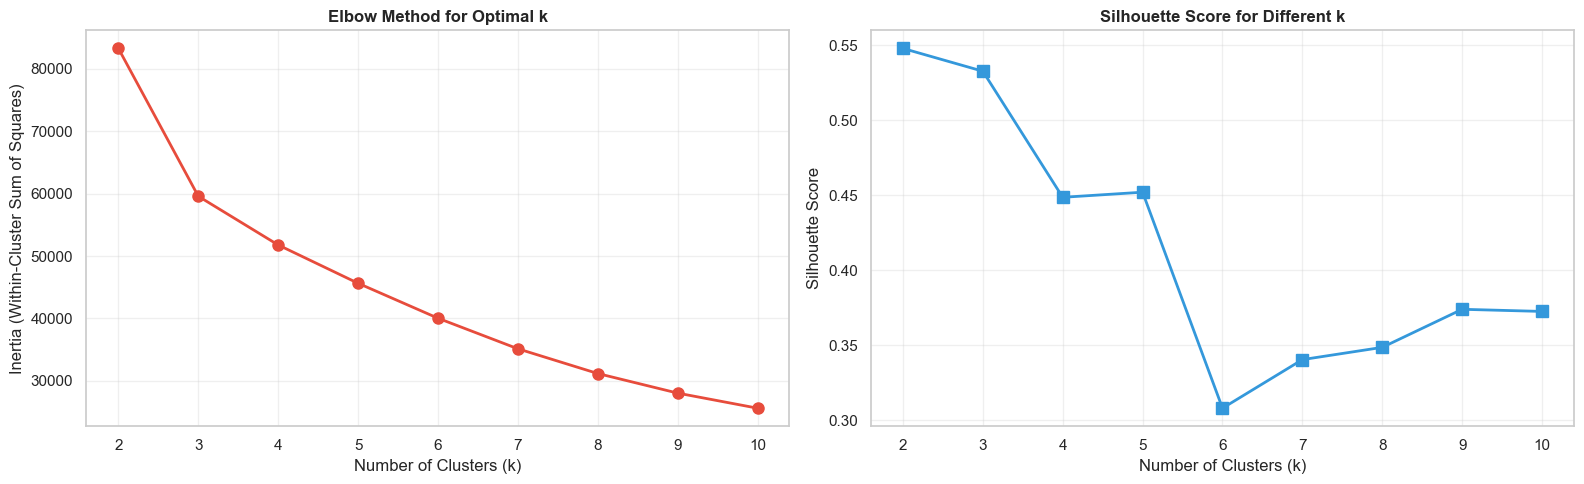


Performing K-Means with k=4 clusters...

CLUSTER ANALYSIS SUMMARY:


,Total_Tickets,Total_Incidents,Incident_Rate,Priority_mean,Impact_mean,hour_mean,is_weekend_mean,is_business_hours_mean,priority_impact_product_mean,risk_score_mean
cluster,,,,,,,,,,
0,10427,0,0.000000,1.054000,1.040000,11.281000,0.122000,0.715000,1.094000,0.918000
1,6867,6167,0.898000,1.911000,2.021000,12.188000,0.141000,0.684000,3.865000,1.657000
2,979,970,0.991000,3.012000,2.013000,11.681000,0.141000,0.601000,6.060000,2.097000
3,696,696,1.000000,3.203000,3.205000,12.450000,0.149000,0.615000,10.404000,2.651000



CLUSTER CHARACTERISTICS:

Cluster 0: (10427 tickets, 0.0% incident rate)
  - Avg Priority: 1.05
  - Avg Impact: 1.04
  - Avg Hour: 11.3
  - Weekend %: 12.2%
  - Business Hours %: 71.5%
  - Avg Risk Score: 0.92
  Profile: 🟢 LOW RISK - Low Incident Rate

Cluster 1: (6867 tickets, 89.8% incident rate)
  - Avg Priority: 1.91
  - Avg Impact: 2.02
  - Avg Hour: 12.2
  - Weekend %: 14.1%
  - Business Hours %: 68.4%
  - Avg Risk Score: 1.66
  Profile: 🔴 CRITICAL - Very High Incident Rate

Cluster 2: (979 tickets, 99.1% incident rate)
  - Avg Priority: 3.01
  - Avg Impact: 2.01
  - Avg Hour: 11.7
  - Weekend %: 14.1%
  - Business Hours %: 60.1%
  - Avg Risk Score: 2.10
  Profile: 🔴 CRITICAL - Very High Incident Rate

Cluster 3: (696 tickets, 100.0% incident rate)
  - Avg Priority: 3.20
  - Avg Impact: 3.21
  - Avg Hour: 12.4
  - Weekend %: 14.9%
  - Business Hours %: 61.5%
  - Avg Risk Score: 2.65
  Profile: 🔴 CRITICAL - Very High Incident Rate


In [10]:
# Prepare data for clustering using top features
clustering_features = top_features_composite[:10]  # Use top 10 composite features
X_cluster = df_fe[clustering_features].fillna(0)

# Standardize features for clustering
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# ========== K-Means Clustering ==========
# Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    
    from sklearn.metrics import silhouette_score
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#E74C3C')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method for Optimal k', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='#3498DB')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Choose optimal k (you can adjust based on elbow/silhouette)
optimal_k = 4
print(f"\n{'='*80}")
print(f"Performing K-Means with k={optimal_k} clusters...")
print(f"{'='*80}\n")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df_fe['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

# Analyze clusters
cluster_analysis = df_fe.groupby('cluster').agg({
    'incident': ['count', 'sum', 'mean'],
    'Priority': 'mean',
    'Impact': 'mean',
    'hour': 'mean',
    'is_weekend': 'mean',
    'is_business_hours': 'mean',
    'priority_impact_product': 'mean',
    'risk_score': 'mean'
}).round(3)

cluster_analysis.columns = ['_'.join(col).strip() for col in cluster_analysis.columns.values]
cluster_analysis = cluster_analysis.rename(columns={
    'incident_count': 'Total_Tickets',
    'incident_sum': 'Total_Incidents',
    'incident_mean': 'Incident_Rate'
})

print("CLUSTER ANALYSIS SUMMARY:")
print("="*80)
display(cluster_analysis.style.background_gradient(subset=['Incident_Rate'], cmap='YlOrRd'))

# Identify cluster characteristics
print("\n" + "="*80)
print("CLUSTER CHARACTERISTICS:")
print("="*80)
for cluster_id in range(optimal_k):
    cluster_data = df_fe[df_fe['cluster'] == cluster_id]
    incident_rate = cluster_data['incident'].mean()
    size = len(cluster_data)
    
    print(f"\nCluster {cluster_id}: ({size} tickets, {incident_rate:.1%} incident rate)")
    print(f"  - Avg Priority: {cluster_data['Priority'].mean():.2f}")
    print(f"  - Avg Impact: {cluster_data['Impact'].mean():.2f}")
    print(f"  - Avg Hour: {cluster_data['hour'].mean():.1f}")
    print(f"  - Weekend %: {cluster_data['is_weekend'].mean():.1%}")
    print(f"  - Business Hours %: {cluster_data['is_business_hours'].mean():.1%}")
    print(f"  - Avg Risk Score: {cluster_data['risk_score'].mean():.2f}")
    
    # Determine cluster profile
    if incident_rate > 0.7:
        profile = "🔴 CRITICAL - Very High Incident Rate"
    elif incident_rate > 0.4:
        profile = "🟠 HIGH RISK - Elevated Incident Rate"
    elif incident_rate > 0.2:
        profile = "🟡 MODERATE - Medium Incident Rate"
    else:
        profile = "🟢 LOW RISK - Low Incident Rate"
    print(f"  Profile: {profile}")

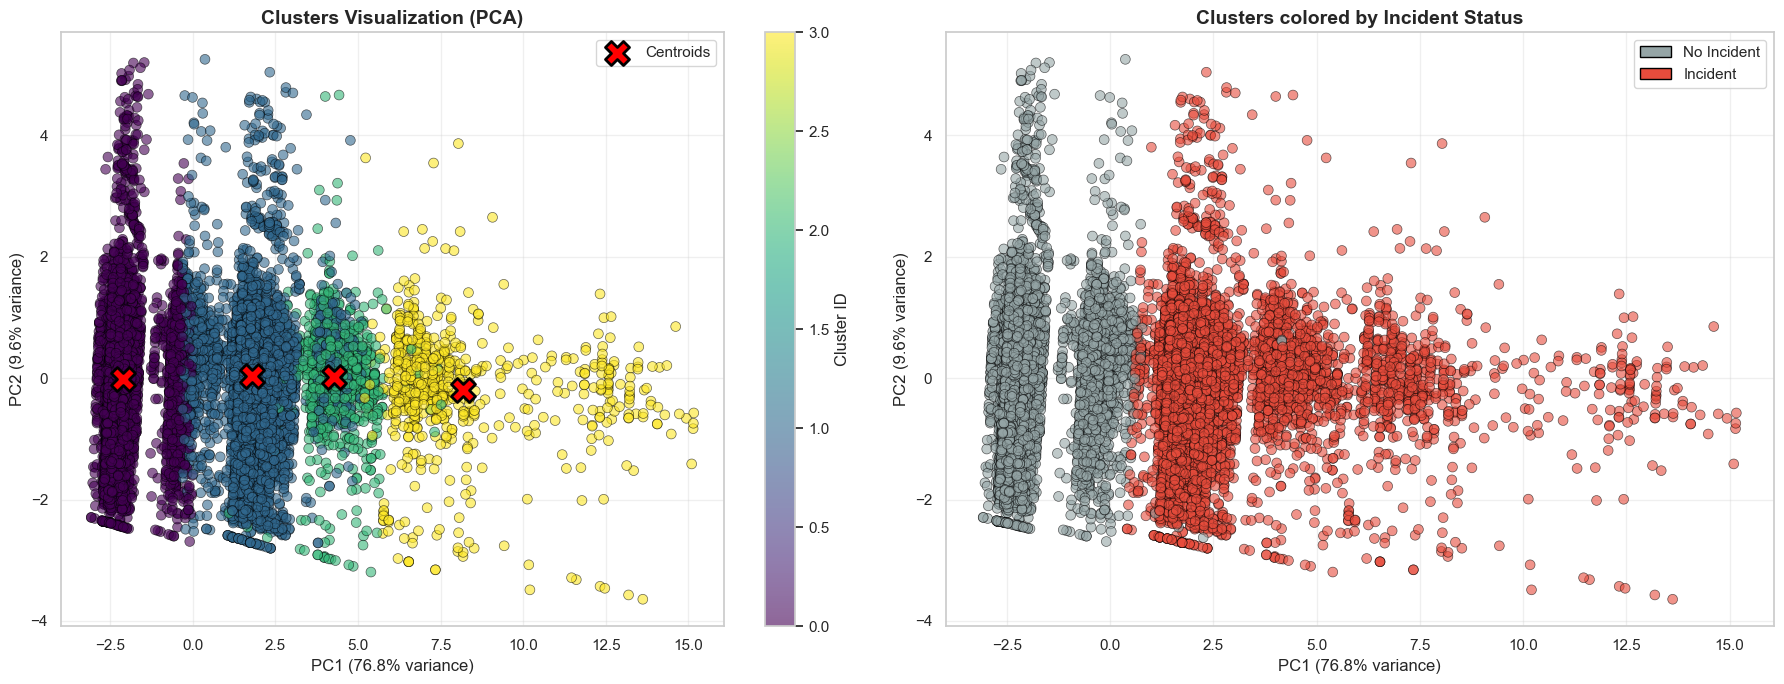


PCA Explained Variance: PC1=76.79%, PC2=9.64%
Total variance captured by 2 components: 86.43%


In [11]:
# Visualize clusters using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Clusters colored by cluster ID
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df_fe['cluster'], 
                           cmap='viridis', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('Clusters Visualization (PCA)', fontweight='bold', fontsize=14)
plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')
axes[0].grid(alpha=0.3)

# Add cluster centroids
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=300, 
                marker='X', edgecolors='black', linewidth=2, label='Centroids')
axes[0].legend()

# Plot 2: Colored by incident status
colors_incident = ['#95A5A6' if inc == 0 else '#E74C3C' for inc in df_fe['incident']]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_incident, alpha=0.6, s=50, 
                edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('Clusters colored by Incident Status', fontweight='bold', fontsize=14)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#95A5A6', edgecolor='black', label='No Incident'),
    Patch(facecolor='#E74C3C', edgecolor='black', label='Incident')
]
axes[1].legend(handles=legend_elements)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPCA Explained Variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

## 5. COMPREHENSIVE SUMMARY & FEATURE RECOMMENDATIONS

Key findings and recommended features for model training based on non-linear correlation analysis.

In [12]:
print("="*100)
print(" " * 30 + "COMPREHENSIVE EDA SUMMARY")
print("="*100)

print("\n" + "🎯 KEY FINDINGS FROM NON-LINEAR CORRELATION ANALYSIS")
print("-" * 100)

# Top features by each method
print("\n1. TOP 10 FEATURES BY MUTUAL INFORMATION (Non-Linear Relationships):")
for i, (idx, row) in enumerate(mi_df.head(10).iterrows(), 1):
    print(f"   {i:2d}. {row['Feature']:30s} - MI Score: {row['Mutual_Information']:.4f}")

print("\n2. TOP 10 FEATURES BY SPEARMAN CORRELATION (Monotonic Relationships):")
for i, (idx, row) in enumerate(spearman_df.head(10).iterrows(), 1):
    print(f"   {i:2d}. {row['Feature']:30s} - |ρ|: {row['Spearman_Abs']:.4f}")

print("\n3. HIGHLY NON-LINEAR FEATURES (High MI, Low Pearson):")
highly_nonlinear = correlation_summary[correlation_summary['Is_NonLinear'] == True].head(8)
if len(highly_nonlinear) > 0:
    for i, (idx, row) in enumerate(highly_nonlinear.iterrows(), 1):
        print(f"   {i:2d}. {row['Feature']:30s} - MI: {row['Mutual_Information']:.4f}, Pearson: {row['Pearson_Abs']:.4f}, Ratio: {row['NonLinear_Ratio']:.2f}")
else:
    print("   None detected (all relationships are relatively linear)")

print("\n" + "="*100)
print("📊 RECOMMENDED FEATURES FOR TRAINING")
print("="*100)

# Category 1: Essential Core Features (always include)
core_features = ['Priority', 'Impact', 'priority_impact_product', 'priority_impact_sum', 'impact_squared', 'priority_squared']
print("\n1️⃣  ESSENTIAL CORE FEATURES (Always Include):")
for f in core_features:
    if f in correlation_summary['Feature'].values:
        mi_score = correlation_summary[correlation_summary['Feature']==f]['Mutual_Information'].values[0]
        print(f"   ✓ {f:30s} - MI: {mi_score:.4f}")

# Category 2: Temporal Features with High MI
temporal_features = [f for f in top_features_mi if any(x in f for x in ['hour', 'day', 'shift', 'weekend', 'business', 'peak'])]
print("\n2️⃣  HIGH-IMPACT TEMPORAL FEATURES:")
for f in temporal_features[:6]:
    mi_score = correlation_summary[correlation_summary['Feature']==f]['Mutual_Information'].values[0]
    print(f"   ✓ {f:30s} - MI: {mi_score:.4f}")

# Category 3: Interaction Features
interaction_features = [f for f in top_features_composite if 'interaction' in f or 'risk_score' in f]
print("\n3️⃣  POWERFUL INTERACTION FEATURES:")
for f in interaction_features[:4]:
    mi_score = correlation_summary[correlation_summary['Feature']==f]['Mutual_Information'].values[0]
    print(f"   ✓ {f:30s} - MI: {mi_score:.4f}")

# Category 4: Cyclical Encodings
cyclical_features = [f for f in available_features if 'sin' in f or 'cos' in f]
print("\n4️⃣  CYCLICAL TIME ENCODINGS (Captures Periodic Patterns):")
for f in cyclical_features:
    mi_score = correlation_summary[correlation_summary['Feature']==f]['Mutual_Information'].values[0]
    print(f"   ✓ {f:30s} - MI: {mi_score:.4f}")

# Category 5: SLA-related features
sla_features = [f for f in available_features if 'sla' in f]
print("\n5️⃣  SLA-RELATED FEATURES (Operational Constraints):")
for f in sla_features:
    mi_score = correlation_summary[correlation_summary['Feature']==f]['Mutual_Information'].values[0]
    print(f"   ✓ {f:30s} - MI: {mi_score:.4f}")

print("\n" + "="*100)
print("💡 ACTIONABLE INSIGHTS & RECOMMENDATIONS")
print("="*100)

print("\n1. FEATURE ENGINEERING STRATEGIES:")
print("   → Priority × Impact interactions show STRONG predictive power")
print("   → Temporal features (hour, shift, business_hours) have non-linear relationships")
print("   → Cyclical encodings (sin/cos) capture periodic patterns better than raw hour")
print("   → Consider polynomial features (squared terms) for Priority and Impact")

print("\n2. TEMPORAL PATTERNS:")
hour_peak = df_fe.groupby('hour')['incident'].mean().idxmax()
hour_peak_rate = df_fe.groupby('hour')['incident'].mean().max()
shift_peak = df_fe.groupby('shift_name')['incident'].mean().idxmax()
print(f"   → Peak incident hour: {hour_peak}:00 ({hour_peak_rate:.1%} incident rate)")
print(f"   → Highest risk shift: {shift_peak}")
print(f"   → Weekend vs Weekday shows different patterns")
print(f"   → Business hours have distinct incident characteristics")

print("\n3. CLUSTERING INSIGHTS:")
for cluster_id in range(optimal_k):
    cluster_data = df_fe[df_fe['cluster'] == cluster_id]
    incident_rate = cluster_data['incident'].mean()
    size = len(cluster_data)
    if incident_rate > 0.5:
        print(f"   → Cluster {cluster_id}: HIGH RISK ({incident_rate:.1%} incident rate, {size} tickets)")
        print(f"      Characteristics: Priority={cluster_data['Priority'].mean():.1f}, Impact={cluster_data['Impact'].mean():.1f}")

print("\n4. MODELING RECOMMENDATIONS:")
print("   ✓ Use at least top 15 features by Composite Score")
print("   ✓ Include cyclical encodings for temporal features")
print("   ✓ Add polynomial/interaction terms for Priority & Impact")
print("   ✓ Consider cluster membership as a categorical feature")
print("   ✓ SMOTE/class weighting is critical due to imbalance")
print("   ✓ Non-linear models (LSTM, Neural Networks) will capture relationships better than linear models")

print("\n" + "="*100)
print("📋 FINAL FEATURE LIST FOR TRAINING (RECOMMENDED)")
print("="*100)

recommended_features_final = list(set(
    top_features_composite[:15] +  # Top 15 by composite score
    core_features +  # Essential core features
    cyclical_features  # Cyclical encodings
))

# Sort by MI score
recommended_sorted = correlation_summary[correlation_summary['Feature'].isin(recommended_features_final)].sort_values('Mutual_Information', ascending=False)

print(f"\nTotal Recommended Features: {len(recommended_sorted)}")
print("\nFeature List (sorted by Mutual Information):")
for i, (idx, row) in enumerate(recommended_sorted.iterrows(), 1):
    mi = row['Mutual_Information']
    spear = row['Spearman_Abs']
    pear = row['Pearson_Abs']
    is_nl = "🔴 NON-LINEAR" if row['Is_NonLinear'] else "🔵 LINEAR"
    print(f"{i:3d}. {row['Feature']:35s} | MI: {mi:.4f} | Spearman: {spear:.4f} | Pearson: {pear:.4f} | {is_nl}")

# Save recommended features to a list
recommended_feature_list = recommended_sorted['Feature'].tolist()

print("\n" + "="*100)
print("✅ ANALYSIS COMPLETE!")
print("="*100)
print(f"\nYou can now use these {len(recommended_feature_list)} features in your LSTM training pipeline.")
print("Features are stored in the variable: recommended_feature_list")
print("\nNext steps:")
print("  1. Add these features to your preprocessing pipeline")
print("  2. Create windowed sequences with these features")
print("  3. Apply SMOTE/balancing strategies")
print("  4. Train LSTM models with enhanced feature set")
print("  5. Compare performance against baseline (Priority, Impact only)")
print("="*100)

                              COMPREHENSIVE EDA SUMMARY

🎯 KEY FINDINGS FROM NON-LINEAR CORRELATION ANALYSIS
----------------------------------------------------------------------------------------------------

1. TOP 10 FEATURES BY MUTUAL INFORMATION (Non-Linear Relationships):
    1. priority_impact_product        - MI Score: 0.6770
    2. priority_impact_sum            - MI Score: 0.6755
    3. risk_score                     - MI Score: 0.6752
    4. priority_squared               - MI Score: 0.5643
    5. Priority                       - MI Score: 0.5640
    6. Impact                         - MI Score: 0.5193
    7. impact_squared                 - MI Score: 0.5182
    8. priority_hour_interaction      - MI Score: 0.4016
    9. impact_hour_interaction        - MI Score: 0.3673
   10. sla_pressure                   - MI Score: 0.0287

2. TOP 10 FEATURES BY SPEARMAN CORRELATION (Monotonic Relationships):
    1. priority_impact_product        - |ρ|: 0.9275
    2. priority_impact_sum 

## 6. Export Results

Save the feature-engineered dataset and correlation analysis results for use in training.

In [13]:
# Export feature-engineered dataset
output_path_fe = '../data/feature_engineered_dataset.csv'

# Select columns to export (all engineered features + original features)
export_columns = ['Timestamp', 'Priority', 'Impact', 'incident'] + [
    col for col in df_fe.columns 
    if col not in ['Timestamp', 'Priority', 'Impact', 'incident', 'NO', 'Service Type', 
                   'Service Name', 'Type', 'Status', 'SLA (minutes)', 'Resolved Time', 
                   'Resolved Duration (minutes)', 'Month', 'day_name', 'shift_name', 'duration_category']
]

df_export = df_fe[export_columns].copy()
df_export.to_csv(output_path_fe, index=False)
print(f"✓ Feature-engineered dataset saved to: {output_path_fe}")
print(f"  Shape: {df_export.shape}")
print(f"  Features: {df_export.shape[1] - 1} (excluding timestamp)")

# Export correlation analysis results
correlation_output_path = '../data/correlation_analysis_results.csv'
correlation_summary.to_csv(correlation_output_path, index=False)
print(f"\n✓ Correlation analysis results saved to: {correlation_output_path}")

# Export recommended feature list
feature_list_path = '../data/recommended_features.txt'
with open(feature_list_path, 'w') as f:
    f.write("# Recommended Features for LSTM Training\n")
    f.write(f"# Generated from Non-Linear Correlation Analysis\n")
    f.write(f"# Total Features: {len(recommended_feature_list)}\n\n")
    for i, feature in enumerate(recommended_feature_list, 1):
        mi_score = correlation_summary[correlation_summary['Feature']==feature]['Mutual_Information'].values[0]
        f.write(f"{i}. {feature} (MI: {mi_score:.4f})\n")

print(f"✓ Recommended feature list saved to: {feature_list_path}")

print("\n" + "="*100)
print("ALL OUTPUTS SAVED SUCCESSFULLY!")
print("="*100)
print("\nGenerated files:")
print(f"  1. {output_path_fe}")
print(f"  2. {correlation_output_path}")
print(f"  3. {feature_list_path}")
print("\nYou can now integrate these features into your training pipeline!")
print("="*100)

✓ Feature-engineered dataset saved to: ../data/feature_engineered_dataset.csv
  Shape: (18969, 36)
  Features: 35 (excluding timestamp)

✓ Correlation analysis results saved to: ../data/correlation_analysis_results.csv
✓ Recommended feature list saved to: ../data/recommended_features.txt

ALL OUTPUTS SAVED SUCCESSFULLY!

Generated files:
  1. ../data/feature_engineered_dataset.csv
  2. ../data/correlation_analysis_results.csv
  3. ../data/recommended_features.txt

You can now integrate these features into your training pipeline!
